# Lab 2 — Hidden Layer Perceptron

Lab 1 showed that a single sigmoid node cannot learn XOR: it can only draw one
straight decision line, and XOR needs two. This lab adds a hidden layer —
`2 inputs -> 4 hidden (sigmoid) -> 1 output (sigmoid)` — and shows that this
extra layer is enough for the network to learn XOR.


In [1]:
import random
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from neural_network.activations import ACTIVATIONS
from neural_network.hyperparameters import random_weights, zero_bias
from neural_network.layer import Layer
from neural_network.network import Network
import trainer.trainer as trainer_module
from trainer.reporter import Reporter
from trainer.trainer import Trainer
from visualizer import GateVisualizer

from data import XOR_INPUTS, XOR_TARGETS

## Building a hidden-layer network

The hidden layer's 4 nodes each get to draw their own line through the input
space; the output node then combines those 4 lines into a single non-linear
boundary — enough to separate `{(0,1), (1,0)}` from `{(0,0), (1,1)}`.

XOR's plateau in Lab 1 took only 500 epochs to show; getting this deeper network
to actually converge needs more epochs, so `MAX_EPOCHS` is raised for this run.

In [2]:
random.seed(1)

hidden_layer = Layer.build(
    input_size=2, output_size=4,
    weight=random_weights(input_size=2, output_size=4), bias=zero_bias(4),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
output_layer = Layer.build(
    input_size=4, output_size=1,
    weight=random_weights(input_size=4, output_size=1), bias=zero_bias(1),
    activation_function=ACTIVATIONS.SIGMOID.function,
    activation_derivative=ACTIVATIONS.SIGMOID.derivative,
)
xor_network = Network(hidden_layer, output_layer)

trainer_module.MAX_EPOCHS = 5000
trainer_module.REPORT_INTERVAL = 500

xor_trainer = Trainer(xor_network)
xor_trainer.train(XOR_INPUTS, XOR_TARGETS)

Epoch: 500/5000 | Average Error: 0.17495518684306216
Epoch: 1000/5000 | Average Error: 0.002882680281141411
Epoch: 1500/5000 | Average Error: 0.0011012668934193897
Epoch: 2000/5000 | Average Error: 0.0006599517222053305
Epoch: 2500/5000 | Average Error: 0.0004654885096843415
Epoch: 3000/5000 | Average Error: 0.00035726544068103154
Epoch: 3500/5000 | Average Error: 0.00028874905564465483
Epoch: 4000/5000 | Average Error: 0.0002416556317062688
Epoch: 4500/5000 | Average Error: 0.00020738594670919748
Epoch: 5000/5000 | Average Error: 0.00018137901714362502
Reached maximum epochs without meeting the error threshold.

Final Error:
Epoch: 5000/5000 | Average Error: 0.00018137901714362502


In [3]:
Reporter.report(xor_network, XOR_INPUTS, XOR_TARGETS)


Layer 0 weights:
[[-2.508483781729617, -2.6182216913368643], [-6.656891144475034, -6.7176404739046625], [-4.155712973528505, -4.177867166606489], [-2.9423480308342596, -2.9417331481269873]]
Layer 0 bias:
[-0.4038381735071612, 2.782213017128542, 6.153637329494698, 4.275593030718595]

Layer 1 weights:
[[-2.058727026477774, -10.666184908395293, 7.53947690451913, 4.665525873520498]]
Layer 1 bias:
[-5.651970598147984]

Inputs: [0, 0] | Target: [0] | Prediction: [0.012180591891166683]
Inputs: [0, 1] | Target: [1] | Prediction: [0.9874087557867544]
Inputs: [1, 0] | Target: [1] | Prediction: [0.987336208177816]
Inputs: [1, 1] | Target: [0] | Prediction: [0.016041450559517542]


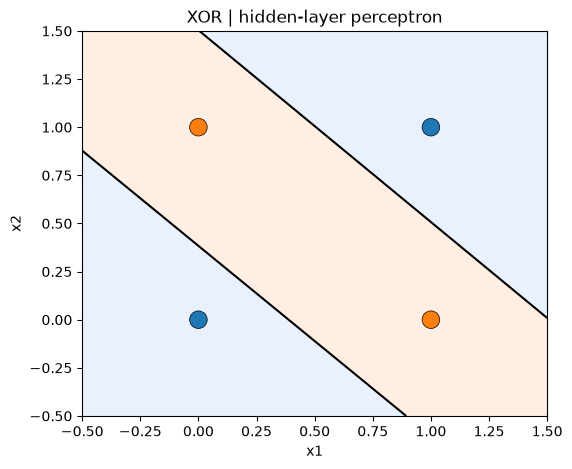

<Axes: title={'center': 'XOR | hidden-layer perceptron'}, xlabel='x1', ylabel='x2'>

In [4]:
GateVisualizer().plot(xor_network, XOR_INPUTS, XOR_TARGETS, title="XOR | hidden-layer perceptron")